## 1. Preporcessing

In [ ]:
import pandas as pd

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv(r"D:\Viki\Guvi DS\Capstone Projects\Amazon Music Clustering\data\single_genre_artists.csv")

print("Data loaded successfully!\n")

# -----------------------------
# 2. INITIAL INSPECTION
# -----------------------------
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# 3. CHECK MISSING VALUES
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# 4. DROP UNNECESSARY COLUMNS (UPDATED)
# -----------------------------
df = df.drop(columns=[
    'explicit',
    'id_songs',
    'name_song',
    'id_artists',
    'name_artists',
    'genres',
    'release_date',
    'key',
    'mode',
    'time_signature',
    'followers',
    'popularity_artists',
    'popularity_songs',
    'duration_ms'   
])

# -----------------------------
# 5. FINAL CHECK AFTER DROPPING
# -----------------------------
print("\nColumns after dropping:")
print(df.columns)

print("\nNew Shape:")
print(df.shape)

print("\nUpdated Info:")
print(df.info())

Data loaded successfully!

First 5 rows:
                 id_songs         name_song  popularity_songs  duration_ms  \
0  0IA0Hju8CAgYfV1hwhidBH           La Java                 0       161427   
1  1b8HZQCqcqwbzlA1jRTp6E          En Douce                 0       223440   
2  5d5gQxHwYovxR5pqETOIAa     J'en Ai Marre                 0       208267   
3  1EO65UEEPfy7CR0NK2sDxy  Ils n'ont pas ca                 0       161933   
4  6a58gXSgqbIsXUhVZ6ZJqe         La belote                 0       167973   

   explicit              id_artists release_date  danceability  energy  key  \
0         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.563   0.184    4   
1         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.427   0.180   10   
2         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.511   0.206    0   
3         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.676   0.467    9   
4         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.650   0.298    9   

   ...  acousti

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# -----------------------------
# DEFINE FEATURES
# -----------------------------
audio_features = df.columns  # all columns are already cleaned features
X = df[audio_features]

# -----------------------------
# SCALING
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview
print("Scaled Data Sample:\n")
print(X_scaled[:5])

# -----------------------------
# CHECK RANGE
# -----------------------------
print("\nMin value:", np.min(X_scaled))
print("Max value:", np.max(X_scaled))

# -----------------------------
# CLIP OUTLIERS (-3 to +3)
# -----------------------------
X_scaled = np.clip(X_scaled, -3, 3)

print("\nAfter Clipping:")
print("Min value:", np.min(X_scaled))
print("Max value:", np.max(X_scaled))

# -----------------------------
# SAVE AS NPY
# -----------------------------
np.save("X_scaled.npy", X_scaled)

print("\nScaled data saved successfully as X_scaled.npy")

In [3]:
# -----------------------------
# SCALING (CONTINUE FROM df)
# -----------------------------
import numpy as np
from sklearn.preprocessing import StandardScaler

# Convert to numpy
X = df.values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview
print("Scaled Data Sample:\n")
print(X_scaled[:5])

# Check range
print("\nBefore Clipping:")
print("Min:", np.min(X_scaled))
print("Max:", np.max(X_scaled))

# -----------------------------
# CLIP OUTLIERS (-3 to +3)
# -----------------------------
X_scaled = np.clip(X_scaled, -3, 3)

print("\nAfter Clipping:")
print("Min:", np.min(X_scaled))
print("Max:", np.max(X_scaled))

# -----------------------------
# SAVE AS NPY
# -----------------------------
np.save("X_scaled.npy", X_scaled)

print("\n✅ X_scaled.npy saved successfully")

Scaled Data Sample:

[[-0.17478473 -0.15347598 -1.51112816 -0.75790895 -0.42710882  1.61618723
  -0.35333823  0.53858362  0.32128698  0.51500516]
 [-0.17478473 -1.02851842 -1.52805562 -1.09862851 -0.36974088  1.60408122
  -0.35340491 -0.52153664 -0.57745518 -1.2944868 ]
 [-0.17478473 -0.48805103 -1.41802711 -1.12789922 -0.39806176  1.62224024
  -0.35340491  1.03904648 -0.37594348 -1.56000306]
 [-0.17478473  0.57358134 -0.31351008 -0.4706769  -0.01391443  1.61013423
  -0.35340491 -0.03183642  0.61146382  0.40526772]
 [-0.17478473  0.40629381 -1.02869543 -0.76822741 -0.11194825  1.61013423
  -0.35340491  0.79688703  1.08703142 -1.37759312]]

Before Clipping:
Min: -8.426625878384142
Max: 5.721323669097489

After Clipping:
Min: -3.0
Max: 3.0

✅ X_scaled.npy saved successfully


In [4]:
# -----------------------------
# OUTLIER DETECTION
# -----------------------------
import pandas as pd
import numpy as np

# Convert scaled data to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

# Summary stats
print("Scaled Data Summary:\n")
print(X_scaled_df.describe())

# Count values beyond ±3
outliers = (X_scaled_df.abs() > 3).sum()

print("\nOutlier count per feature:\n")
print(outliers)

# -----------------------------
# CHECK OUTLIERS FOR A FEATURE
# -----------------------------
outlier_idx = X_scaled_df['instrumentalness'].abs() > 3
df_outliers = df[outlier_idx]

print("\nSample Outliers (instrumentalness):\n")
print(df_outliers.head())

Scaled Data Summary:

           explicit  danceability        energy      loudness   speechiness  \
count  95837.000000  95837.000000  9.583700e+04  95837.000000  9.583700e+04   
mean      -0.080671      0.001090  7.592013e-17      0.008723 -7.592013e-17   
std        0.538457      0.996410  1.000005e+00      0.966210  1.000005e+00   
min       -0.174785     -3.000000 -2.289708e+00     -3.000000 -6.130100e-01   
25%       -0.174785     -0.636036 -7.451604e-01     -0.540169 -4.891969e-01   
50%       -0.174785      0.116758  3.879876e-03      0.160223 -4.452632e-01   
75%       -0.174785      0.728001  7.867751e-01      0.729844 -2.390291e-01   
max        3.000000      2.600334  1.942075e+00      3.000000  2.901684e+00   

       acousticness  instrumentalness      liveness       valence  \
count  9.583700e+04      95837.000000  95837.000000  9.583700e+04   
mean  -9.490016e-17         -0.026889     -0.012785  4.448445e-17   
std    1.000005e+00          0.907024      0.955895  1.0000

Correlation Matrix:

                  explicit  danceability    energy  loudness  speechiness  \
explicit          1.000000      0.112600  0.105021  0.111540     0.019971   
danceability      0.112600      1.000000  0.204810  0.161041     0.229137   
energy            0.105021      0.204810  1.000000  0.734616    -0.096334   
loudness          0.111540      0.161041  0.734616  1.000000    -0.254914   
speechiness       0.019971      0.229137 -0.096334 -0.254914     1.000000   
acousticness     -0.114057     -0.186992 -0.663945 -0.457045     0.137110   
instrumentalness -0.041422     -0.189374 -0.130171 -0.229224    -0.138109   
liveness         -0.025468     -0.030714  0.082891 -0.045746     0.407153   
valence          -0.027132      0.504279  0.361499  0.235866     0.026236   
tempo             0.002871     -0.083170  0.210389  0.190798    -0.204813   

                  acousticness  instrumentalness  liveness   valence     tempo  
explicit             -0.114057         -0.041422 -

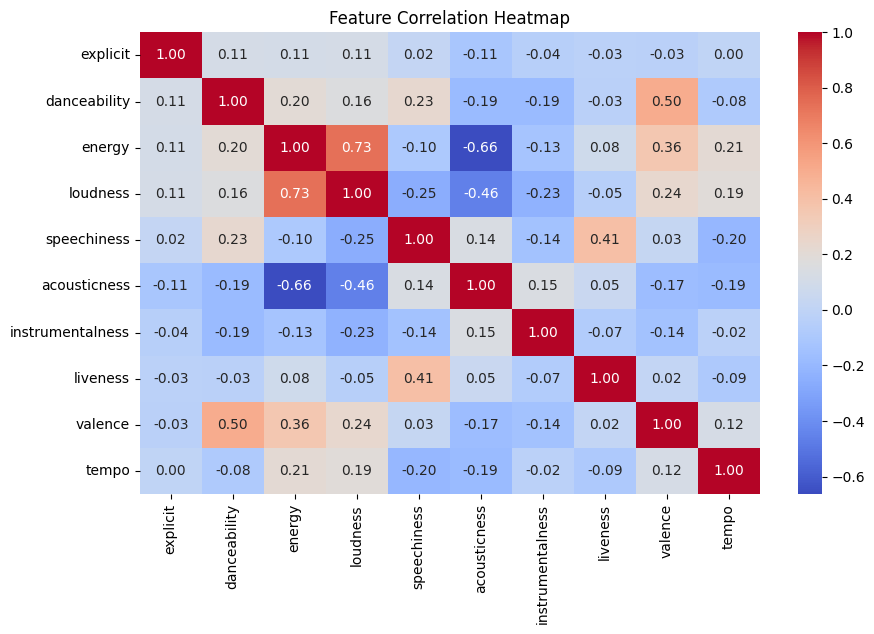

In [5]:
# -----------------------------
# CORRELATION CHECK (FROM df)
# -----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr()

# Print matrix
print("Correlation Matrix:\n")
print(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()